In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from STiMetaD import STiMetaD

base_path = Path("../data/chignolin/output")
colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]

rmsd_threshold = 0.18
estimator = STiMetaD(minSampleSize=10)

results = []

for i in range(100, 150):
    index_str = f"{i:03}"
    run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

    df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")

    above_threshold = df[df["rmsd"] > rmsd_threshold]
    if above_threshold.empty:
        print(f"No frame above threshold in run {index_str}")
        continue

    first_hit = above_threshold.iloc[0]
     # Convert to MD steps (2 fs per step)
    time = first_hit["time"] 
    acc = first_hit["metad.acc"]
    predicted = time * acc
    
    # print(f"{time}, {acc}, {predicted}")
    

    results.append(predicted)

samples = np.array(results)

print(f"MFPT (μs): {estimator.estimateMFPT(samples=samples) / 1e6}")

# plt.figure(figsize=(6, 4))
# plt.hist(results, bins=30)
# plt.xlabel("Predicted First-Passage Time (ns)")
# plt.ylabel("Count")
# plt.title("Predicted FPT Distribution")
# plt.tight_layout()
# plt.savefig("figures/fpt_histogram.png")


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f27050404f0>>
Traceback (most recent call last):
  File "/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


No frame above threshold in run 109


Estimated mean transition time (tau): 7638829613930.7891


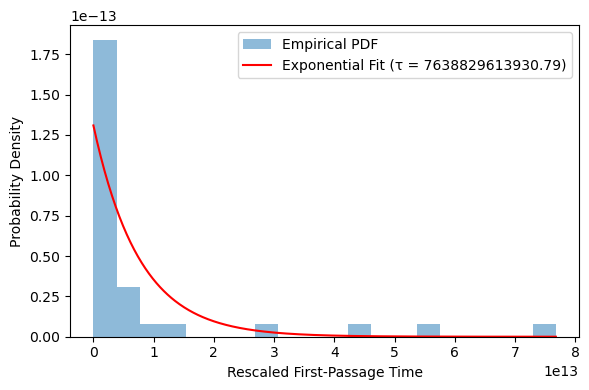

In [2]:
from scipy.stats import expon

# Fit the exponential distribution
loc, tau = expon.fit(samples, floc=0)  # force loc=0
print(f"Estimated mean transition time (tau): {tau:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
count, bins, ignored = plt.hist(samples, bins=20, density=True, alpha=0.5, label="Empirical PDF")
x = np.linspace(0, max(samples), 500)
plt.plot(x, expon.pdf(x, scale=tau), 'r-', label=f"Exponential Fit (τ = {tau:.2f})")
plt.xlabel("Rescaled First-Passage Time")
plt.ylabel("Probability Density")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

mu = np.mean(samples)
sigma = np.std(samples)
mean_std_ratio = mu / sigma
print(f"μ / σ = {mean_std_ratio:.3f} (should be ≈ 1)")

median = np.median(samples)
median_meanln2_ratio = median / (mu * np.log(2))
print(f"median / (μ ln 2) = {median_meanln2_ratio:.3f} (should be ≈ 1)")


from scipy.stats import expon, kstest

# Fit exponential (assumes transitions start at t=0)
loc, tau = expon.fit(samples, floc=0)

# Run KS test
D, p_value = kstest(samples, 'expon', args=(0, tau))
print(f"KS test statistic: {D:.4f}")
print(f"KS test p-value: {p_value} (should be > 0.05 to pass)")


μ / σ = 0.439 (should be ≈ 1)
median / (μ ln 2) = 0.051 (should be ≈ 1)
KS test statistic: 0.5417
KS test p-value: 7.181782453053975e-10 (should be > 0.05 to pass)
